In [33]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

from clustering.leiden.fit import fit_umap_leiden
from visualization.plot import plot_clustering_on_umap
from visualization.samples_plot import show_clustering_samples

PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings_224"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")
print(embedding.shape[1])
n_samples = embedding.shape[0]

1664


In [34]:
X_reduced_variance = VarianceThreshold(threshold=1e-8).fit_transform(embedding)

embedding_scaled = StandardScaler().fit_transform(X_reduced_variance)

pca_95 = PCA(n_components=0.95, svd_solver="full")
pca_95_embedding = pca_95.fit_transform(embedding_scaled)

print("Shape dopo PCA:", pca_95_embedding.shape)

pca_95_embedding_l2 = normalize(pca_95_embedding, norm="l2")

Shape dopo PCA: (677, 315)


In [35]:
from clustering.leiden.score import local_structure_per_cluster_consensus, consensus_param_metrics_leiden, \
    consensus_param_score_leiden
from clustering.leiden.consensus import consensus_clustering_from_labels_leiden
from clustering.leiden.params import make_umap_leiden_grid_params
from clustering.hdbscan.score import consensus_param_score, consensus_param_metrics
import pandas as pd
from tqdm.auto import tqdm

params = make_umap_leiden_grid_params(
    n_components_values=[10, 15, 20, 30],
    n_neighbors_values=[
        0.03 * n_samples,
        0.05 * n_samples,
        0.075 * n_samples
    ],
    k_neighbors_values=[
        (0.025 * n_samples),
        (0.035 * n_samples),
        (0.05 * n_samples),
        (0.075 * n_samples),
        (0.1 * n_samples),
    ],
    resolution_values=[0.3, 0.45, 0.6]
)

candidate_results = []

for config_id, param in enumerate(tqdm(params, desc="Grid search consensus")):
    labels_for_consensus = []
    umap_embeddings_for_consensus = []

    for seed in range(0, 25):
        labels, umap_embedding, _, _ = fit_umap_leiden(
            X=pca_95_embedding_l2,
            seed=None,
            n_components=param["n_components"],
            n_neighbors=param["n_neighbors"],
            k=param["k_neighbors"],
            resolution=param["resolution"]
        )

        labels_for_consensus.append(labels)
        umap_embeddings_for_consensus.append(umap_embedding)

    consensus_labels, consensus_probabilities, diagnostics = consensus_clustering_from_labels_leiden(
        label_runs=labels_for_consensus,
        n_clusters="median",
        min_consensus_strength=0.70,
        mark_unstable_as_noise=False,
        return_diagnostics=True,
    )

    local_consensus = local_structure_per_cluster_consensus(
        consensus_labels=consensus_labels,
        X_ref=pca_95_embedding_l2,  # spazio di riferimento, NON UMAP
        k=20,
        metric="cosine",
        ignore_noise=True,
    )

    metrics = consensus_param_metrics_leiden(
        local_consensus_df=local_consensus,
        consensus_labels=consensus_labels,
        probabilities=consensus_probabilities,
    )

    score = consensus_param_score_leiden(
        metrics=metrics,
        min_clusters=3,
        max_clusters=12,
        max_unstable=0.30,
        max_dominance=0.70,
    )

    candidate_results.append({
        "config_id": config_id,
        **param,
        "score": score,
        **metrics,
        "consensus_labels": consensus_labels,
        "probabilities": consensus_probabilities,
        "local_consensus_df": local_consensus,
    })

Grid search consensus:   0%|          | 0/120 [00:00<?, ?it/s]

In [36]:
exclude_keys = [
    "consensus_labels",
    "probabilities",
    "consensus_stability",
    "local_consensus_df",
    "diagnostics",
]

results_df = pd.DataFrame([
    {
        k: v
        for k, v in result.items()
        if k not in exclude_keys
    }
    for result in candidate_results
])

results_df = results_df.sort_values(
    "score",
    ascending=False
).reset_index(drop=True)

results_df

,config_id,k_neighbors,n_components,n_neighbors,resolution,score,n_clusters,unstable_ratio,dominance,effective_n_clusters,balance_score,min_cluster_size,micro_cluster_ratio,mean_consensus_probability,local_agreement,weighted_edge_cut,normalized_knn_label_entropy
0,119,68,30,51,1,0.795527,7,0.0,0.192024,6.470558,0.924365,53,0.0,0.921064,0.754505,0.229033,0.284737
1,103,68,15,20,1,0.795252,6,0.0,0.199409,5.790272,0.965045,72,0.0,0.894827,0.758863,0.223175,0.307887
2,97,68,10,20,1,0.794051,6,0.0,0.196455,5.803322,0.967220,70,0.0,0.888996,0.757903,0.222990,0.309964
3,99,68,10,34,1,0.792779,6,0.0,0.215657,5.743543,0.957257,69,0.0,0.889493,0.757976,0.224715,0.308991
4,109,68,20,20,1,0.791664,6,0.0,0.209749,5.746856,0.957809,72,0.0,0.874608,0.759010,0.222639,0.308133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,106,68,15,51,0,-inf,1,0.0,1.000000,1.000000,1.000000,677,0.0,1.000000,1.000000,0.000000,0.000000
116,114,68,30,20,0,-inf,1,0.0,1.000000,1.000000,1.000000,677,0.0,1.000000,1.000000,0.000000,0.000000
117,112,68,20,51,0,-inf,1,0.0,1.000000,1.000000,1.000000,677,0.0,1.000000,1.000000,0.000000,0.000000
118,116,68,30,34,0,-inf,1,0.0,1.000000,1.000000,1.000000,677,0.0,0.979980,1.000000,0.000000,0.000000


In [37]:
best_config_id = int(results_df.iloc[0]["config_id"])

best_result = next(
    result for result in candidate_results
    if result["config_id"] == best_config_id
)

best_consensus_labels = best_result["consensus_labels"]
best_probabilities = best_result["probabilities"]  # oppure consensus_stability
best_local_consensus_df = best_result["local_consensus_df"]

best_result_summary = {
    k: v
    for k, v in best_result.items()
    if k not in [
        "consensus_labels",
        "probabilities",
        "consensus_stability",
        "local_consensus_df",
        "diagnostics",
    ]
}

best_result_summary

{'config_id': 119,
 'k_neighbors': 68,
 'n_components': 30,
 'n_neighbors': 51,
 'resolution': 1,
 'score': 0.7955272948258759,
 'n_clusters': 7,
 'unstable_ratio': 0.0,
 'dominance': 0.19202363367799113,
 'effective_n_clusters': 6.470557508505923,
 'balance_score': 0.924365358357989,
 'min_cluster_size': 53,
 'micro_cluster_ratio': 0.0,
 'mean_consensus_probability': 0.9210637807846069,
 'local_agreement': 0.7545051698670606,
 'weighted_edge_cut': 0.2290325508683233,
 'normalized_knn_label_entropy': 0.28473729218156824}

In [38]:
best_local_consensus_df = best_result["local_consensus_df"]

cols = [
    "cluster",
    "n_samples",
    "local_agreement_mean",
    "local_agreement_median",
    "edge_cut_ratio_mean",
    "weighted_edge_cut_ratio_mean",
    "knn_entropy_mean",
    "normalized_entropy_mean",
]

global_row = best_local_consensus_df[
    best_local_consensus_df["cluster"] == "global"
]

cluster_rows = best_local_consensus_df[
    best_local_consensus_df["cluster"] != "global"
].copy()

cluster_rows["cluster"] = cluster_rows["cluster"].astype(int)

display(
    pd.concat(
        [
            global_row,
            cluster_rows.sort_values("cluster")
        ],
        ignore_index=True
    )[cols]
)

,cluster,n_samples,local_agreement_mean,local_agreement_median,edge_cut_ratio_mean,weighted_edge_cut_ratio_mean,knn_entropy_mean,normalized_entropy_mean
0,global,677,0.754505,0.80,0.245495,0.229033,0.554073,0.284737
1,0,130,0.740000,0.80,0.260000,0.241970,0.592434,0.304451
2,1,53,0.566038,0.60,0.433962,0.403737,0.946295,0.486300
3,2,107,0.777103,0.75,0.222897,0.212035,0.514399,0.264349
4,3,96,0.750000,0.75,0.250000,0.230383,0.515983,0.265163
5,4,127,0.915748,0.95,0.084252,0.078559,0.240102,0.123388
6,5,61,0.652459,0.65,0.347541,0.319504,0.649628,0.333843
7,6,103,0.712136,0.70,0.287864,0.271161,0.711090,0.365428


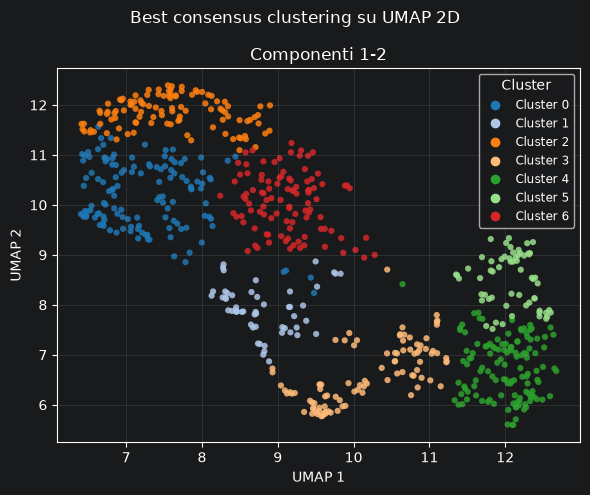

In [39]:
plot_figure, plot_axes = plot_clustering_on_umap(
    pca_95_embedding_l2,
    best_consensus_labels,
    title="Best consensus clustering su UMAP 2D",
    metric="euclidean",
    min_dist=0.05,
    n_neighbors=int(best_result["n_neighbors"]),
)

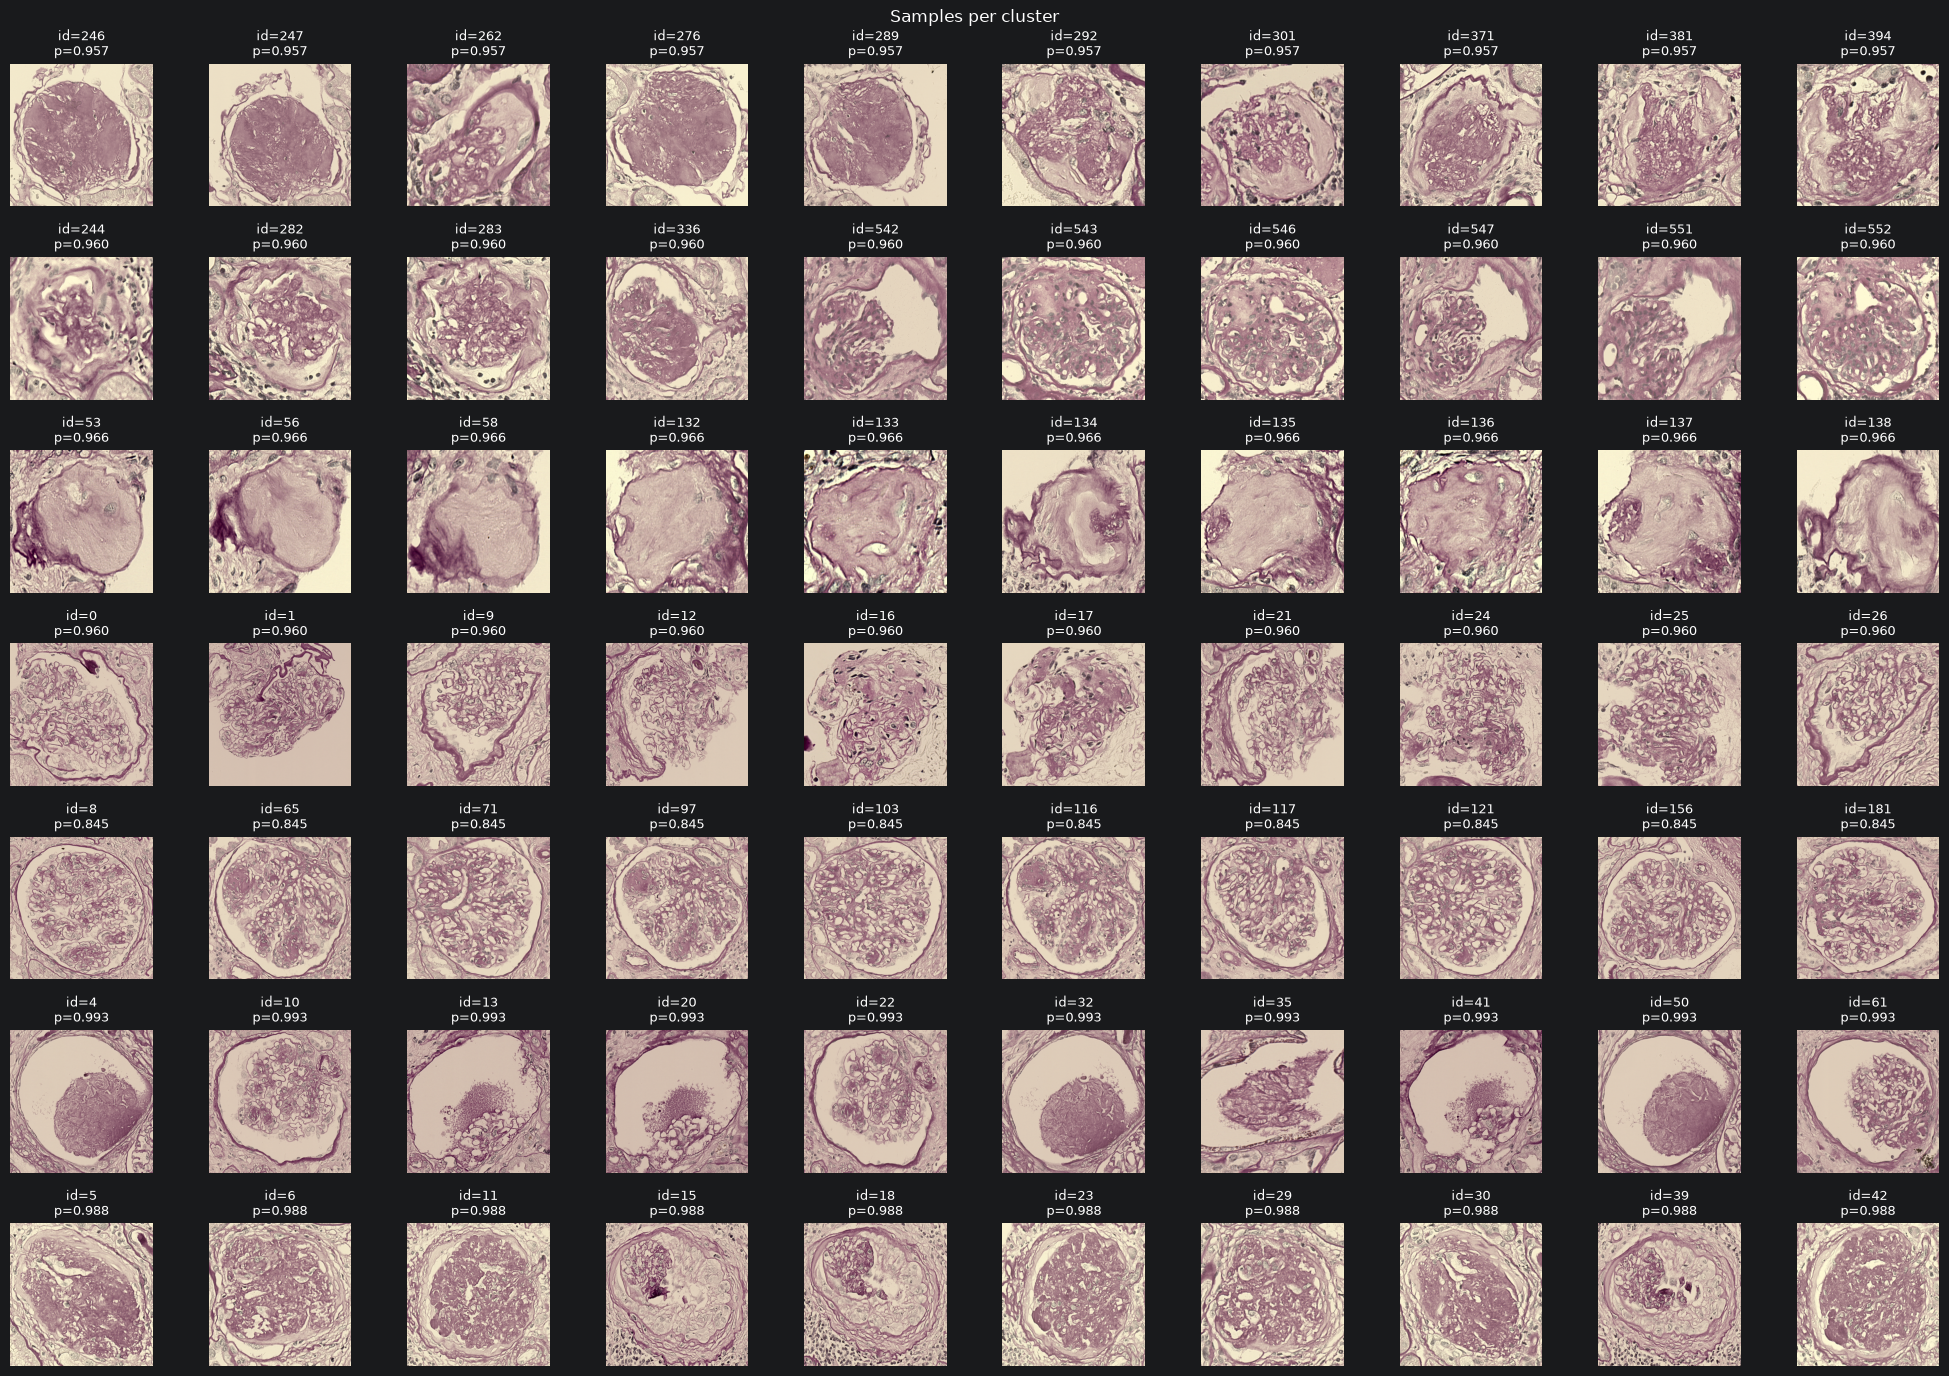

In [40]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=best_consensus_labels,
    probabilities=best_probabilities,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)

In [41]:
from sklearn.metrics import pairwise_distances


def pair_rank_report(X, idx_a, idx_b, metric="cosine", name="space"):
    """
    Dice quanto idx_b ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ vicino a idx_a nello spazio X.
    rank = 1 significa vicino pi﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ vicino.
    rank alto significa lontano.
    """
    D = pairwise_distances(X, X[[idx_a]], metric=metric).ravel()

    order = np.argsort(D)
    order = order[
        order != idx_a]  # rimuove s﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ stesso

    rank_b = np.where(order == idx_b)[0][0] + 1
    dist_ab = D[idx_b]

    percent_rank = rank_b / (len(X) - 1) * 100

    print(f"\n{name}")
    print(f"metric: {metric}")
    print(f"distanza {idx_a} -> {idx_b}: {dist_ab:.4f}")
    print(f"rank del secondo rispetto al primo: {rank_b}/{len(X) - 1}")
    print(f"percentile rank: {percent_rank:.2f}%")

    return {
        "space": name,
        "distance": dist_ab,
        "rank": rank_b,
        "percent_rank": percent_rank,
    }

In [42]:
ID_SCLEROTIC = 4
ID_OPEN = 3

In [43]:
# Distanza originale tra due punti nello spazio embedding
report_pre = pair_rank_report(
    embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="RAW"
)

post_variance_threshold = pair_rank_report(
    X_reduced_variance,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="POST-VarianceThreshold"
)

post_pca = pair_rank_report(
    pca_95_embedding_l2,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="cosine",
    name="POST-PCA"
)

post_umap = pair_rank_report(
    umap_embedding,
    ID_SCLEROTIC,
    ID_OPEN,
    metric="euclidean",
    name="POST-UMAP"
)


RAW
metric: cosine
distanza 4 -> 3: 0.2981
rank del secondo rispetto al primo: 224/676
percentile rank: 33.14%

POST-VarianceThreshold
metric: cosine
distanza 4 -> 3: 0.2981
rank del secondo rispetto al primo: 224/676
percentile rank: 33.14%

POST-PCA
metric: cosine
distanza 4 -> 3: 0.8990
rank del secondo rispetto al primo: 117/676
percentile rank: 17.31%

POST-UMAP
metric: euclidean
distanza 4 -> 3: 2.1294
rank del secondo rispetto al primo: 128/676
percentile rank: 18.93%


In [44]:
import numpy as np
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import dijkstra, connected_components


def compute_graph_pseudotime(
    X_ref,
    k,
    metric="cosine",
    start_idx=None,
):
    """
    Calcola uno pseudotime morfologico su grafo kNN.

    X_ref: embedding di riferimento, es. pca_95_embedding_l2
    k: numero di vicini
    metric: "cosine" per PCA/L2
    start_idx: indice del glomerulo iniziale. Se None, sceglie automaticamente un estremo.
    """

    n_samples = X_ref.shape[0]

    G = kneighbors_graph(
        X_ref,
        n_neighbors=k,
        mode="distance",
        metric=metric,
        include_self=False,
    )

    # Simmetrizza il grafo
    G = G.maximum(G.T).tocsr()

    n_components, component_labels = connected_components(
        G,
        directed=False,
        return_labels=True,
    )

    if n_components > 1:
        print(
            f"Attenzione: grafo non connesso. "
            f"Componenti = {n_components}. "
            f"Valuta di aumentare k."
        )

    # Se non dai uno start, sceglie automaticamente un estremo del grafo
    if start_idx is None:
        largest_component = np.argmax(np.bincount(component_labels))
        valid_idx = np.where(component_labels == largest_component)[0]

        seed_idx = valid_idx[0]

        dist_from_seed = dijkstra(
            G,
            directed=False,
            indices=seed_idx,
        )

        dist_from_seed[~np.isfinite(dist_from_seed)] = -np.inf
        endpoint_a = int(np.argmax(dist_from_seed))

        dist_from_a = dijkstra(
            G,
            directed=False,
            indices=endpoint_a,
        )

        dist_from_a[~np.isfinite(dist_from_a)] = -np.inf
        endpoint_b = int(np.argmax(dist_from_a))

        start_idx = endpoint_a

    distances = dijkstra(
        G,
        directed=False,
        indices=start_idx,
    )

    finite_mask = np.isfinite(distances)

    pseudotime = np.full(n_samples, np.nan, dtype=float)

    d = distances[finite_mask]

    if d.max() > d.min():
        pseudotime[finite_mask] = (d - d.min()) / (d.max() - d.min())
    else:
        pseudotime[finite_mask] = 0.0

    info = {
        "graph": G,
        "start_idx": start_idx,
        "n_components": n_components,
        "component_labels": component_labels,
    }

    return pseudotime, info

In [45]:
pseudotime, pseudo_info = compute_graph_pseudotime(
    X_ref=pca_95_embedding_l2,
    k=round(0.05 * n_samples),
    metric="cosine",
    start_idx=None,
)

In [46]:
import umap

umap_2d = umap.UMAP(
    n_neighbors=round(0.075 * n_samples),
    min_dist=0.05,
    n_components=2,
    metric="cosine",
    random_state=42,
).fit_transform(pca_95_embedding_l2)

/home/pasquale/PycharmProjects/Glomeruli-FP03-2026/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


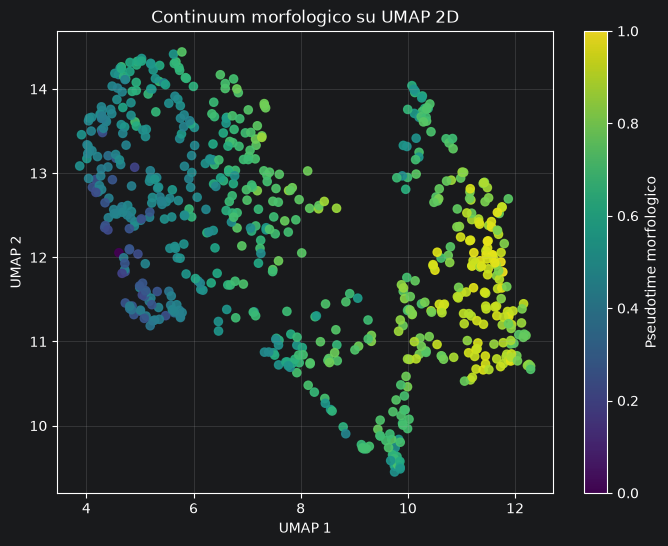

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=pseudotime,
    s=35,
    cmap="viridis",
    alpha=0.9,
)

plt.colorbar(sc, label="Pseudotime morfologico")
plt.title("Continuum morfologico su UMAP 2D")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.25)
plt.show()

In [48]:
import pandas as pd

cluster_order_df = pd.DataFrame({
    "cluster": best_consensus_labels,
    "pseudotime": pseudotime,
})

cluster_order_df = (
    cluster_order_df
    .groupby("cluster")
    .agg(
        n_samples=("pseudotime", "size"),
        pseudotime_mean=("pseudotime", "mean"),
        pseudotime_median=("pseudotime", "median"),
        pseudotime_min=("pseudotime", "min"),
        pseudotime_max=("pseudotime", "max"),
    )
    .sort_values("pseudotime_median")
    .reset_index()
)

cluster_order_df

,cluster,n_samples,pseudotime_mean,pseudotime_median,pseudotime_min,pseudotime_max
0,0,130,0.427885,0.449713,0.000000,0.716866
1,2,107,0.508104,0.489229,0.228295,0.737064
2,1,53,0.645381,0.672997,0.462319,0.779410
3,6,103,0.671608,0.691533,0.443345,0.848548
4,5,61,0.716215,0.721085,0.489410,0.937471
5,3,96,0.741830,0.734078,0.455384,0.954718
6,4,127,0.884870,0.906110,0.710505,1.000000


In [49]:
import numpy as np
import pandas as pd

# Rimuovi eventuale riga global
cluster_order_df_clean = cluster_order_df[
    cluster_order_df["cluster"] != "global"
].copy()

# Forza i cluster a interi
cluster_order_df_clean["cluster"] = pd.to_numeric(
    cluster_order_df_clean["cluster"]
).astype(int)

# Lista ordinata dei cluster originali
ordered_clusters = cluster_order_df_clean["cluster"].tolist()

# Dizionario cluster originale -> stage ordinato
cluster_to_stage = {
    int(cluster): int(stage)
    for stage, cluster in enumerate(ordered_clusters)
}

# Crea stage labels
stage_labels = np.array([
    cluster_to_stage[int(c)]
    for c in best_consensus_labels
], dtype=int)

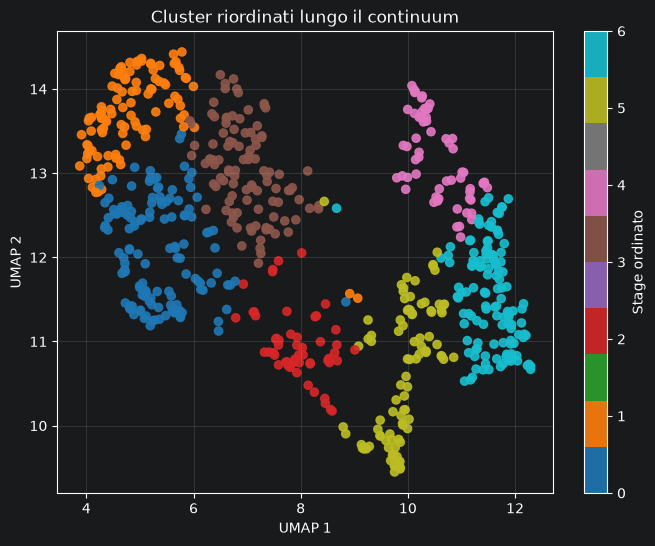

In [50]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=stage_labels,
    s=35,
    cmap="tab10",
    alpha=0.9,
)

plt.colorbar(sc, label="Stage ordinato")
plt.title("Cluster riordinati lungo il continuum")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.25)
plt.show()

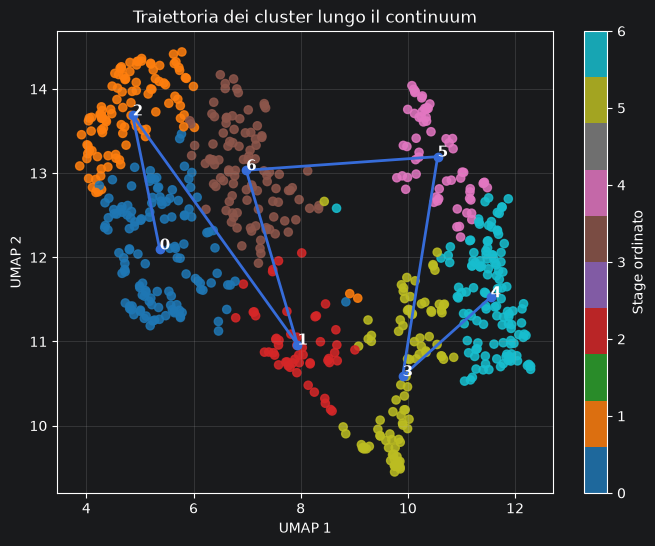

In [51]:
cluster_centroids = []

for cluster_id in ordered_clusters:
    idx = np.where(best_consensus_labels == cluster_id)[0]

    centroid = umap_2d[idx].mean(axis=0)

    cluster_centroids.append({
        "cluster": cluster_id,
        "x": centroid[0],
        "y": centroid[1],
    })

centroids_df = pd.DataFrame(cluster_centroids)

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=stage_labels,
    s=35,
    cmap="tab10",
    alpha=0.85,
)

plt.plot(
    centroids_df["x"],
    centroids_df["y"],
    linewidth=2,
    marker="o",
)

for _, row in centroids_df.iterrows():
    plt.text(
        row["x"],
        row["y"],
        str(int(row["cluster"])),
        fontsize=11,
        weight="bold",
    )

plt.colorbar(sc, label="Stage ordinato")
plt.title("Traiettoria dei cluster lungo il continuum")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.25)
plt.show()